In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
output_path = '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/cgmvae_test'
epoch = 10000
dataset_abbrev =  ['Geno', 'Physio']
geno_dim = 5873
physio_dim = 33

In [3]:
input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_restandardized_cfc.csv')
input_data

,MouseID,0.1,1,2,3,4,5,6,7,8,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num,Diet,Mouse.ID,CFC.24mo.Average,cfc_bin
0,DO-1D-3001,0.885234,1.036678,1.103385,1.452176,-0.252292,1.184701,0.381302,-0.684006,1.182885,...,-0.011158,0.770557,1.927418,-0.322225,-1.087006,4,1D,DO-1D-3001,0.84,0
1,DO-1D-3003,1.156802,-0.055468,-2.028303,-1.758717,-1.483365,0.146188,0.546376,1.862347,-0.141052,...,-0.411678,0.293438,1.927418,-0.403810,-1.019388,4,1D,DO-1D-3003,83.69,4
2,DO-1D-3010,0.147212,-0.629090,0.095689,-0.822066,-1.147267,0.014700,0.237685,-1.764237,-1.134055,...,-0.305292,0.824915,1.927418,-0.403810,-1.373187,4,1D,DO-1D-3010,36.71,1
3,DO-1D-3011,0.501676,-1.656495,0.752401,-0.348172,1.043520,-0.411199,1.418046,-1.336511,-0.988819,...,0.057679,1.283924,1.927418,-0.595036,-0.783522,4,1D,DO-1D-3011,21.96,1
4,DO-1D-3013,-1.894295,-0.589873,0.736833,0.101999,-0.042866,0.525641,-0.812557,0.540155,0.514178,...,-0.217680,-0.891058,1.927418,-0.364648,1.002585,4,1D,DO-1D-3013,6.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,DO-AL-0186,-0.408746,0.723953,-0.114496,0.852664,-0.156098,-0.293482,0.724477,-1.353684,-0.640700,...,0.128756,-0.891058,-0.296149,-0.939946,1.002585,5,AL,DO-AL-0186,20.44,1
497,DO-AL-0188,0.885158,-0.713064,0.707135,-0.531217,1.003639,1.606643,0.987814,-0.958576,-1.891393,...,0.247655,0.910384,-0.779282,-0.175043,-1.225502,5,AL,DO-AL-0188,18.31,0
498,DO-AL-0191,0.269565,0.035678,-0.173052,-1.004266,-1.580964,0.475946,0.805426,0.353003,0.781255,...,-0.109053,-0.891058,0.048480,0.288994,1.002585,5,AL,DO-AL-0191,24.71,1
499,DO-1D-3083,-1.650913,0.649956,-0.438226,0.676653,-0.926468,1.070770,0.104359,0.712658,1.142204,...,1.192684,1.821772,-1.509398,-0.981960,-1.069439,4,1D,DO-1D-3083,31.07,1


Examine original input distributions

In [4]:
# Genoprob distributions
np.max(input_data.iloc[:, 1:geno_dim]), np.min(input_data.iloc[:, 1:geno_dim]), np.std(input_data.iloc[:, 1:geno_dim]).mean(), np.mean(input_data.iloc[:, 1:geno_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(5.407817280582792,
 -5.626699932437837,
 0.9985042217540192,
 2.3131236987350902e-05)

In [5]:
# Physiological measures distributions
np.max(input_data.iloc[:, geno_dim+3:geno_dim+physio_dim+3]), np.min(input_data.iloc[:, geno_dim+3:geno_dim+physio_dim+3]), np.std(input_data.iloc[:, geno_dim+3:geno_dim+physio_dim+3]).mean(), np.mean(input_data.iloc[:, geno_dim+3:geno_dim+physio_dim+3])

(4.905619567652551,
 -5.397022540655006,
 0.8249790852339546,
 -0.013291419463533453)

Load in final reconstructions

In [6]:
original_geno = input_data.iloc[:, 1:geno_dim]
original_physio = input_data.iloc[:, geno_dim+3:geno_dim+physio_dim+3]

In [7]:
Physio_from_Geno = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[1]}_epoch{epoch}_vae{dataset_abbrev[0]}.csv'))
Physio_from_Geno

,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,Y3_Echo_BPM,Y1_Echo_CardiacOutput,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,cfm,lifespan,orig_lifespan,bin,orig_cfm
0,0.073394,-0.170346,-0.786700,-0.189443,-0.373029,-0.946503,-0.007098,-0.647765,0.527621,-0.057518,...,-0.026436,0.635839,-0.197112,-0.367815,-0.947365,-1.625460,-0.623599,-0.621813,0,-1.790642
1,-0.199191,-0.169791,-0.786709,-0.199427,-0.130294,-0.952018,-0.005819,-0.406749,0.527621,-0.057518,...,0.163714,0.869484,0.056430,-0.279289,-0.962877,1.583167,-0.429754,-0.453265,3,1.537107
2,-0.429932,-0.769011,-0.786713,-0.200178,-0.612219,-0.952083,-0.297710,-0.583862,-1.597096,-0.537599,...,-0.115464,0.875510,0.669435,-0.218844,-0.966354,-0.292820,0.962541,0.900743,1,-0.349890
3,-0.226503,-0.495224,-0.786713,-0.167847,-0.593605,-0.952081,-0.142828,-0.622054,0.382590,-0.227311,...,0.598564,0.875480,0.862582,-0.297885,-0.966303,-0.989867,0.149539,0.204075,0,-0.942337
4,0.070209,-0.197946,-0.501173,-0.176676,-0.263471,0.933693,-0.006530,-0.533941,0.527621,-0.057518,...,-0.148273,-0.893167,0.885610,-0.243361,0.992092,-1.501989,-1.081100,-1.093750,0,-1.546032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.785344,0.147860,1.192412,-0.201196,-0.233309,0.938691,-0.005954,-0.476411,0.527621,-0.057518,...,-0.113993,-0.894892,0.518672,-0.050051,1.016570,-0.932771,-1.409525,-1.520740,0,-1.003389
497,-0.225679,-0.536978,-0.786713,-0.161968,-0.599601,-0.952030,-0.052069,-0.659923,0.527486,-0.078191,...,0.380728,0.875110,0.507985,-0.297606,-0.965789,-1.066327,-0.177329,-0.183587,0,-1.088943
498,0.053318,-0.041637,-0.784445,-0.010951,-0.003478,0.938733,-0.605707,-0.664540,0.527621,-0.057518,...,0.011374,-0.878458,0.553683,-0.162334,1.009456,-0.895722,-1.019834,-0.975766,1,-0.831881
499,0.466513,0.328920,-0.786713,0.453598,-0.059939,-0.950817,-0.227479,-0.217338,0.527616,-0.057518,...,0.596180,0.871610,-0.342371,-0.452841,-0.965191,-0.560774,0.040655,0.063618,1,-0.576425


In [8]:
np.max(Physio_from_Geno.iloc[:, :geno_dim]), np.min(Physio_from_Geno.iloc[:, :geno_dim]), np.std(Physio_from_Geno.iloc[:, :geno_dim]).mean()

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(3.729362, -2.6205285, 0.5202333047817764)

In [9]:
Physio_from_Physio = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[1]}_epoch{epoch}_vae{dataset_abbrev[1]}.csv'))
Physio_from_Physio

,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,Y3_Echo_BPM,Y1_Echo_CardiacOutput,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,cfm,lifespan,orig_lifespan,bin,orig_cfm
0,0.104547,-0.149263,-0.793769,-0.163000,-0.418061,-0.527653,-0.016495,-0.634323,0.545330,-0.060591,...,0.161890,-0.067740,0.321882,-0.319764,-0.609776,-1.615862,-0.485918,-0.621813,0,-1.790642
1,-0.295309,-0.140315,-0.793772,-0.252950,-0.111324,-0.940495,-0.004022,-0.158159,0.545330,-0.065249,...,0.306548,0.884361,0.107652,-0.410750,-0.967070,1.355875,-0.424417,-0.453265,3,1.537107
2,-0.464598,-0.991358,-0.793795,-0.252887,-0.578255,-0.940569,-0.127343,-0.520805,-1.603080,-0.562144,...,0.024508,0.885945,0.139885,-0.440815,-0.967806,-0.341594,0.895675,0.900743,1,-0.349890
3,-0.168580,-0.467805,-0.793795,-0.251123,-0.571811,-0.940513,-0.029723,-0.567657,0.544499,-0.060593,...,0.407467,0.884155,0.459004,-0.406785,-0.967287,-1.141928,0.052012,0.204075,0,-0.942337
4,-0.106464,-0.579545,-0.146738,0.022452,-0.471776,0.963975,-0.011018,-0.731398,0.545330,-0.060591,...,-0.544511,-0.920440,0.552563,-0.204753,1.012328,-1.514832,-1.205528,-1.093750,0,-1.546032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.406201,-0.184665,1.035265,0.072497,-0.399486,0.963972,-0.005665,-0.563857,0.545330,-0.060591,...,-0.201919,-0.920466,0.193942,-0.057449,1.013010,-1.086127,-1.300497,-1.520740,0,-1.003389
497,-0.243747,-0.475749,-0.793794,-0.228018,-0.651170,-0.940381,-0.018424,-0.563461,0.545330,-0.060591,...,0.501120,0.879274,0.376950,-0.433058,-0.964871,-1.043682,-0.083204,-0.183587,0,-1.088943
498,0.456611,0.336194,-0.172063,-0.239737,-0.228564,0.964028,-0.351905,-0.441967,0.545330,-0.060591,...,0.352363,-0.918798,0.021945,-0.432817,1.011493,-0.602931,-1.218370,-0.975766,1,-0.831881
499,0.124563,0.273291,-0.793795,-0.038603,-0.069168,-0.940211,-0.170057,-0.209173,0.545234,-0.060591,...,0.390475,0.881278,-0.089369,-0.299129,-0.966648,-0.604619,0.070910,0.063618,1,-0.576425


Text(0.5, 0.98, 'Physio reconstructions')

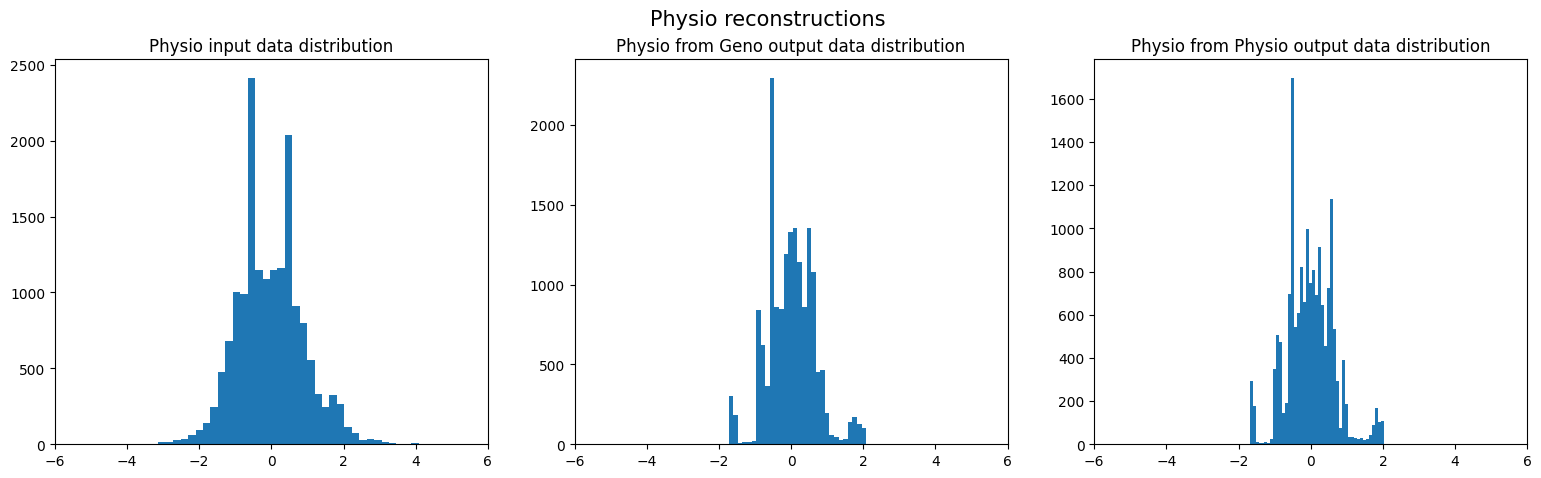

In [10]:
fig, ax = plt.subplots(1, 3, figsize = (19, 5))
ax[0].hist(original_physio.values.flatten(), bins=50)
ax[0].set_title('Physio input data distribution')
ax[0].set_xlim(-6, 6)
ax[1].hist(Physio_from_Geno.iloc[:, :physio_dim].values.flatten(), bins=50)
ax[1].set_title('Physio from Geno output data distribution')
ax[1].set_xlim(-6, 6)
ax[2].hist(Physio_from_Physio.iloc[:, :physio_dim].values.flatten(), bins=50)
ax[2].set_title('Physio from Physio output data distribution')
ax[2].set_xlim(-6, 6)
fig.suptitle('Physio reconstructions', fontsize=15)

In [11]:
Geno_from_Physio = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[0]}_epoch{epoch}_vae{dataset_abbrev[1]}.csv'))
Geno_from_Geno = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[0]}_epoch{epoch}_vae{dataset_abbrev[0]}.csv'))

In [12]:
Geno_from_Geno

,0,1,2,3,4,5,6,7,8,9,...,5868,5869,5870,5871,5872,cfm,lifespan,orig_lifespan,bin,orig_cfm
0,0.069453,0.399811,-0.088093,0.391045,-0.703109,0.275754,-0.420357,0.229614,-0.100822,0.224639,...,0.451133,0.201335,0.151829,-0.125023,-0.181038,-1.730582,-0.588761,-0.621813,0,-1.790642
1,-0.002713,0.394360,0.202675,-0.251820,-0.063952,-0.421201,-0.768350,0.173467,0.212752,0.136810,...,-0.280133,-0.082448,-0.019693,-0.010899,-0.035099,1.519233,-0.364613,-0.453265,3,1.537107
2,0.188606,0.335402,-0.268776,-0.220780,0.084627,-0.483223,0.181557,-0.020344,-0.074717,-0.416819,...,-0.310872,-0.385942,0.192866,-0.154010,-0.211888,-0.387226,0.965438,0.900743,1,-0.349890
3,0.693278,-0.338957,0.673375,-0.023454,0.683825,-0.086427,0.211392,-0.460589,-0.024704,0.386396,...,0.105700,-0.142063,0.216031,-0.013391,-0.375094,-0.925521,0.267188,0.204075,0,-0.942337
4,-0.875424,-0.790222,0.007887,0.401686,0.007041,0.255993,0.085539,-0.073897,-0.161545,-0.025983,...,0.245858,0.005282,0.411172,-0.341257,-0.360958,-1.558694,-1.158172,-1.093750,0,-1.546032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.007220,-0.081580,0.333731,0.012951,-0.276109,-0.131032,0.330118,-0.007089,-0.295767,-0.543118,...,0.031838,-0.097096,0.354233,0.526381,0.029618,-0.983186,-1.422672,-1.520740,0,-1.003389
497,0.152491,-0.017575,0.143059,-0.224832,0.415586,0.545719,-0.196394,-0.398545,-0.040315,0.146707,...,-0.169835,-0.302897,-0.165508,0.142855,-0.339652,-1.044547,-0.253129,-0.183587,0,-1.088943
498,-0.178175,-0.337968,-0.260912,-0.006077,-0.200435,0.101657,-0.633476,-0.020494,-0.244686,-0.888810,...,0.057197,0.247241,-0.137209,0.135983,0.054224,-0.771387,-0.985513,-0.975766,1,-0.831881
499,-0.138510,0.445030,0.247569,0.735181,-0.540610,0.652525,-0.519095,0.738196,0.318419,-0.074313,...,0.152918,-0.328289,-0.242026,-0.144771,-0.425291,-0.568432,0.065641,0.063618,1,-0.576425


Text(0.5, 0.98, 'Geno reconstructions')

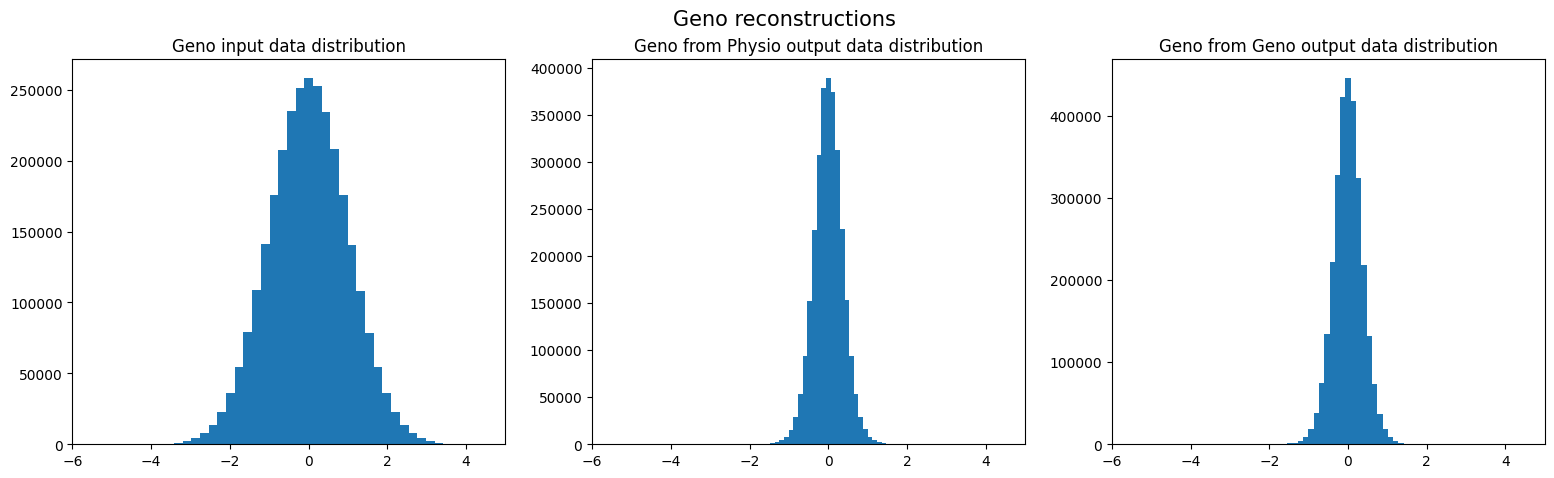

In [13]:
fig, ax = plt.subplots(1, 3, figsize = (19, 5))
ax[0].hist(original_geno.values.flatten(), bins=50)
ax[0].set_title('Geno input data distribution')
ax[0].set_xlim(-6, 5)
ax[1].hist(Geno_from_Physio.iloc[:, :geno_dim].values.flatten(), bins=50)
ax[1].set_title('Geno from Physio output data distribution')
ax[1].set_xlim(-6, 5)
ax[2].hist(Geno_from_Geno.iloc[:, :geno_dim].values.flatten(), bins=50)
ax[2].set_title('Geno from Geno output data distribution')
ax[2].set_xlim(-6, 5)
fig.suptitle('Geno reconstructions', fontsize=15)

Examine CFM and lifespan reconstructions

In [14]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    return (input_array - mean)/std

In [15]:
def unstandardize(input_array, mean, std):
    return input_array * std + mean

In [16]:
stats_cfm = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/stats_cfm.csv')
stats_lifespan = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/stats_cfm.csv')

In [17]:
original_cfm = unstandardize(Geno_from_Geno['orig_cfm'], float(stats_cfm['mean']), float(stats_cfm['std']))
original_lifespan = unstandardize(Geno_from_Geno['orig_lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std']))

/tmp/ipykernel_1482693/554534741.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  original_cfm = unstandardize(Geno_from_Geno['orig_cfm'], float(stats_cfm['mean']), float(stats_cfm['std']))
/tmp/ipykernel_1482693/554534741.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  original_lifespan = unstandardize(Geno_from_Geno['orig_lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std']))


/tmp/ipykernel_1482693/2272422639.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[1].hist(unstandardize(Geno_from_Geno['cfm'], float(stats_cfm['mean']), (float(stats_cfm['std']))), bins=50)
/tmp/ipykernel_1482693/2272422639.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[2].hist(unstandardize(Geno_from_Physio['cfm'], float(stats_cfm['mean']), float(stats_cfm['std'])), bins=50)
/tmp/ipykernel_1482693/2272422639.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[3].hist(unstandardize(Physio_from_Physio['cfm'], float(stats_cfm['mean']), float(stats_cfm['std'])), bins=50)
/tmp/ipykernel_1482693/2272422639.py:14: FutureWarning: Calling float on a single element Series is deprecate

Text(0.5, 0.98, 'CFM reconstructions')

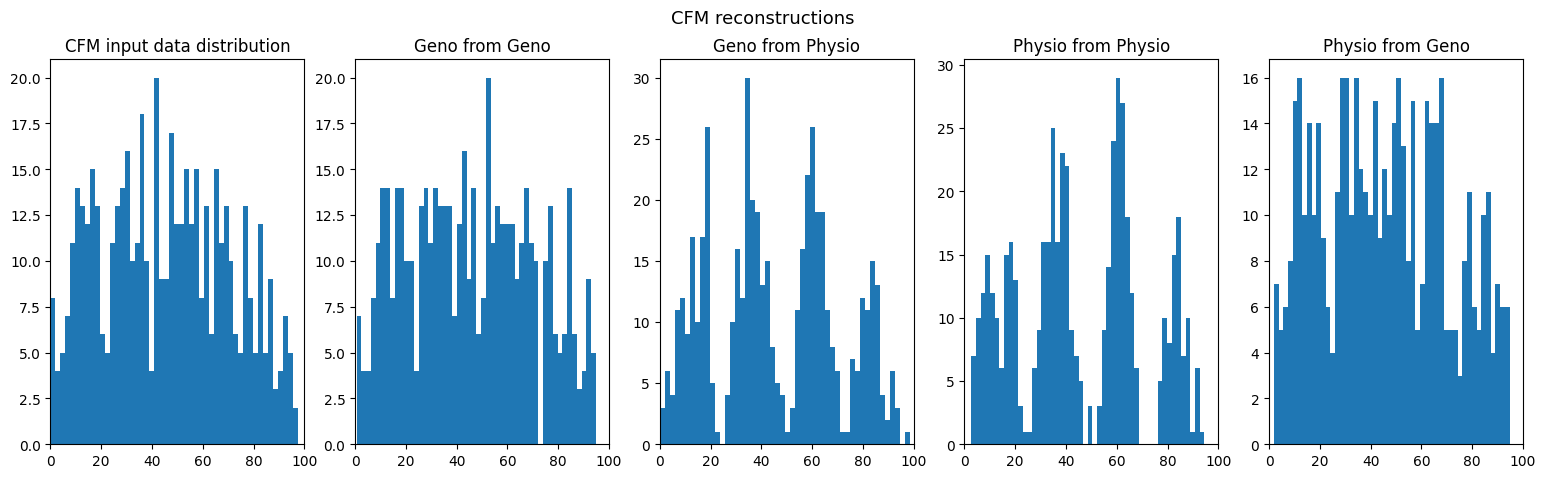

In [18]:
fig, ax = plt.subplots(1, 5, figsize = (19, 5))
ax[0].hist(original_cfm, bins=50)
ax[0].set_title('CFM input data distribution')
ax[0].set_xlim(0, 100)
ax[1].hist(unstandardize(Geno_from_Geno['cfm'], float(stats_cfm['mean']), (float(stats_cfm['std']))), bins=50)
ax[1].set_title('Geno from Geno')
ax[1].set_xlim(0, 100)
ax[2].hist(unstandardize(Geno_from_Physio['cfm'], float(stats_cfm['mean']), float(stats_cfm['std'])), bins=50)
ax[2].set_title('Geno from Physio')
ax[2].set_xlim(0, 100)
ax[3].hist(unstandardize(Physio_from_Physio['cfm'], float(stats_cfm['mean']), float(stats_cfm['std'])), bins=50)
ax[3].set_title('Physio from Physio')
ax[3].set_xlim(0, 100)
ax[4].hist(unstandardize(Physio_from_Geno['cfm'], float(stats_cfm['mean']), float(stats_cfm['std'])), bins=50)
ax[4].set_title('Physio from Geno')
ax[4].set_xlim(0, 100)
fig.suptitle('CFM reconstructions', fontsize=13)

/tmp/ipykernel_1482693/1575140728.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[1].hist(unstandardize(Geno_from_Geno['lifespan'], float(stats_lifespan['mean']), (float(stats_lifespan['std']))), bins=50)
/tmp/ipykernel_1482693/1575140728.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[2].hist(unstandardize(Geno_from_Physio['lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std'])), bins=50)
/tmp/ipykernel_1482693/1575140728.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[3].hist(unstandardize(Physio_from_Physio['lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std'])), bins=50)
/tmp/ipykernel_1482693/1575140728.py:14: FutureWarning: Calling 

Text(0.5, 0.98, 'Lifespan reconstructions')

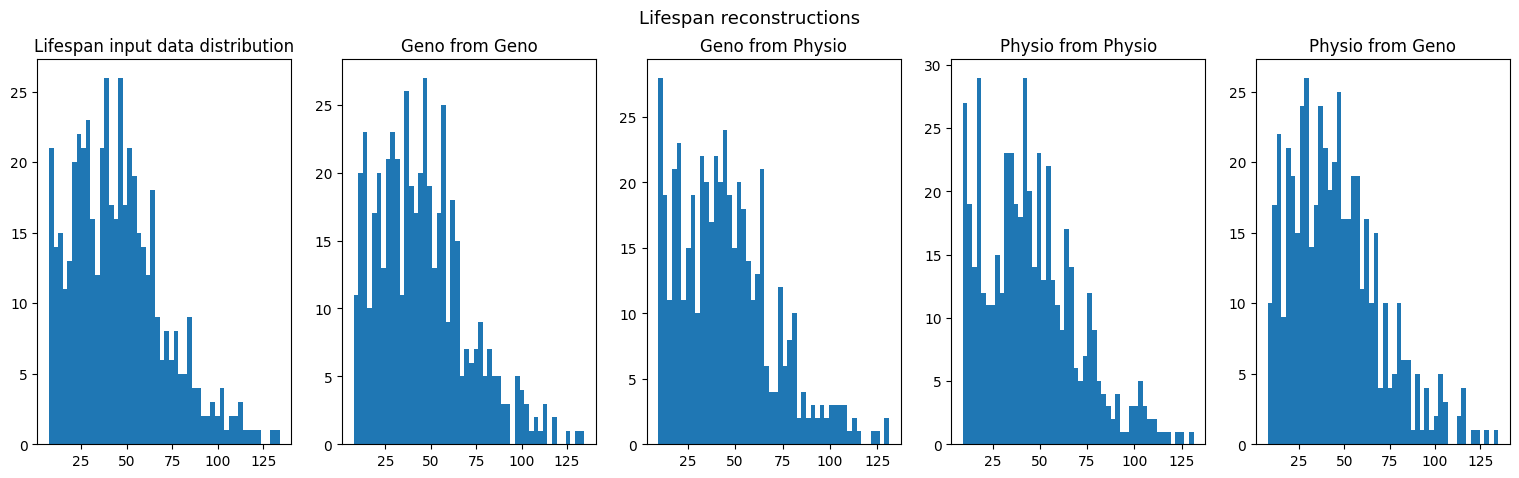

In [19]:
fig, ax = plt.subplots(1, 5, figsize = (19, 5))
ax[0].hist(original_lifespan, bins=50)
ax[0].set_title('Lifespan input data distribution')
#ax[0].set_xlim(0, 100)
ax[1].hist(unstandardize(Geno_from_Geno['lifespan'], float(stats_lifespan['mean']), (float(stats_lifespan['std']))), bins=50)
ax[1].set_title('Geno from Geno')
#ax[1].set_xlim(0, 100)
ax[2].hist(unstandardize(Geno_from_Physio['lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std'])), bins=50)
ax[2].set_title('Geno from Physio')
#ax[2].set_xlim(0, 100)
ax[3].hist(unstandardize(Physio_from_Physio['lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std'])), bins=50)
ax[3].set_title('Physio from Physio')
#ax[3].set_xlim(0, 100)
ax[4].hist(unstandardize(Physio_from_Geno['lifespan'], float(stats_lifespan['mean']), float(stats_lifespan['std'])), bins=50)
ax[4].set_title('Physio from Geno')
#ax[4].set_xlim(0, 100)
fig.suptitle('Lifespan reconstructions', fontsize=13)